In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from lingam import VARLiNGAM
from sklearn.preprocessing import StandardScaler
from scipy import stats

warnings.filterwarnings('ignore')

In [2]:
def VARLiNGAM_generate(adj : np.ndarray, noise : np.ndarray) -> np.ndarray:
    d0, n_features, _ = adj.shape
    lags = d0 - 1
    n_samples = noise.shape[0]

    # Generate
    out = np.copy(noise)
    B = np.linalg.inv(np.eye(n_features) - adj[0])

    for i in range(lags):
        out[i] = B @ out[i]
    for i in range(lags, n_samples):
        for tau in range(1, lags + 1):
            out[i] += adj[tau] @ out[i - tau]
        out[i] = B @ out[i]

    return out

In [3]:
n_samples = 1000
n_features = 4

# adj（x0 -> x1 -> x2 -> x3）
adj_varlingam = np.array(
    [
        # B0 (동일 시간대 사이의 직접효과。VAR-LiNGAM에서는 이것울 비순환한다고 가정한다.
        [[0, 0, 0, 0], [0.2, 0, 0, 0], [0, 0.2, 0, 0], [0, 0, 0.2, 0]],
        # B1 (1기간전부터의 직접효과)
        [[0.8, 0, 0, 0], [0, 0.8, 0, 0], [0, 0, 0.8, 0], [0, 0, 0, 0.8]],
        # B2 (2기간전부터의 직접효과)
        [[0, 0, 0, 0], [0, 0, 0, 0], [0.2, 0, 0, 0], [0, 0.2, 0, 0]],
        # B3 (3기간전부터의 직접효과를 가정)
        [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0.1, 0, 0, 0]],
    ]
)

In [16]:
# 데이터 X로 데이터프레임 작성
np.random.seed(0)
X_varlingam = VARLiNGAM_generate(
    adj=adj_varlingam,
    noise=np.random.uniform(low=-0.1, high=0.1, size=(n_samples, n_features)),
) * 0.01
df = pd.DataFrame(
    data=X_varlingam,
    index=pd.date_range(start="1999-05-28", periods=n_samples, freq="D"),
    columns=[f"x{i}" for i in range(n_features)],
)

<Axes: >

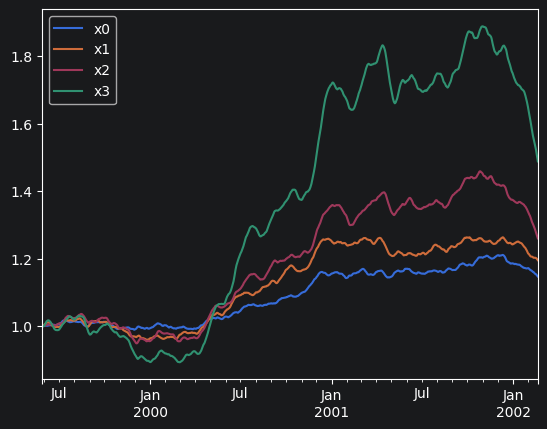

In [17]:
(1 + df).cumprod().plot()

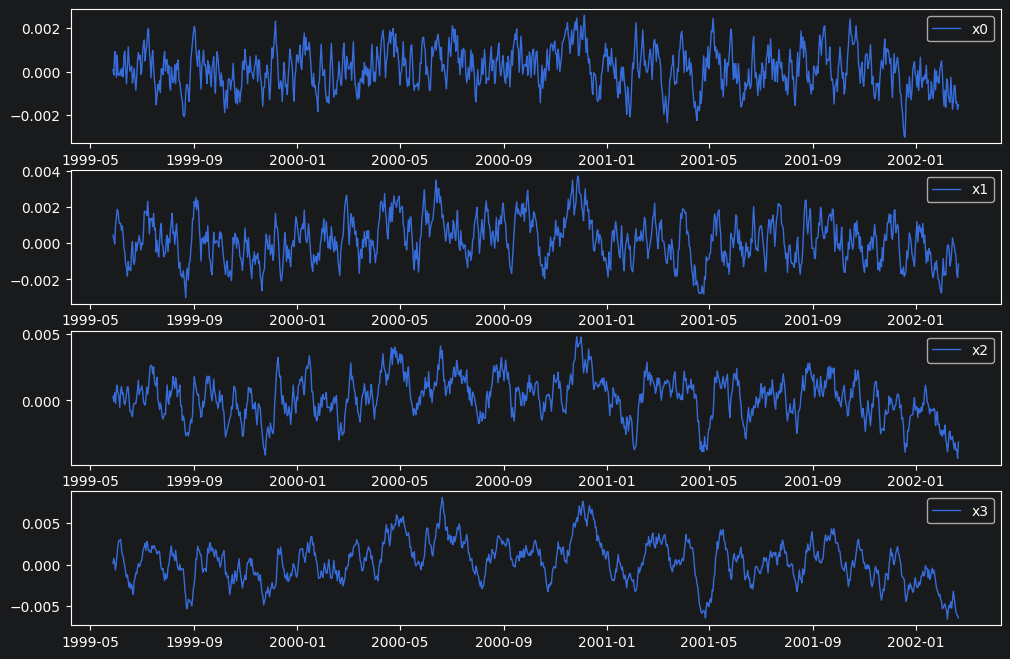

In [18]:
fig, axes = plt.subplots(n_features, 1, figsize=(12, 2 * n_features))

for col, ax in zip(df.columns, axes):
    ax.plot(df[col], label=col, linewidth=1)
    ax.legend()

### 전처리 (표준화)

In [20]:
sc = StandardScaler()
X_scaled = sc.fit_transform(df)  # Xを標準化したX_scaled(np.ndarray)を計算
df_scaled = pd.DataFrame(data=X_scaled, index=df.index, columns=df.columns)

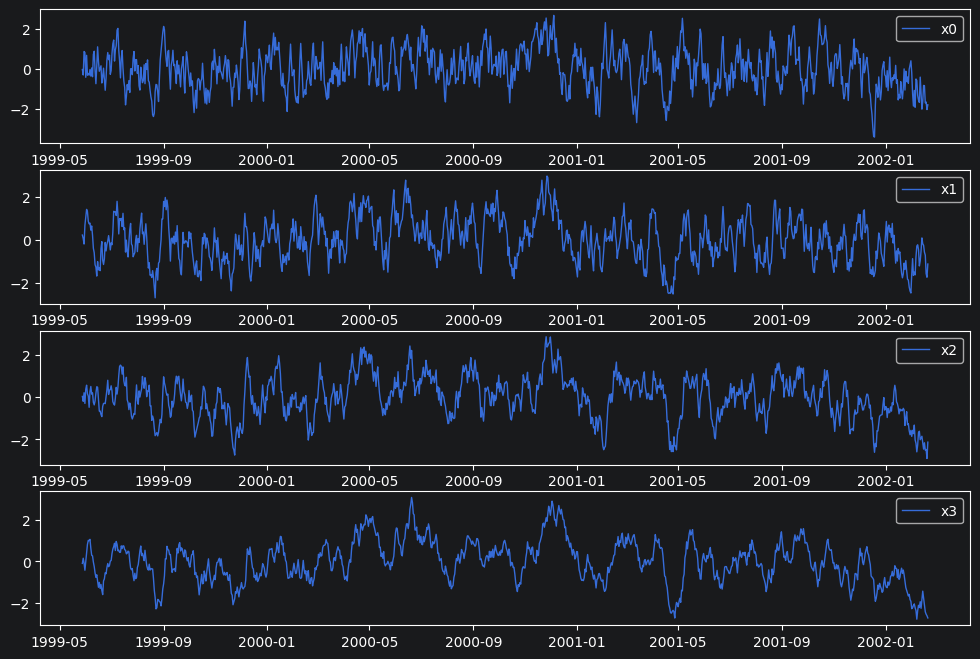

In [23]:
fig, axes = plt.subplots(n_features, 1, figsize=(12, 2 * n_features))

for col, ax in zip(df_scaled.columns, axes):
    ax.plot(df_scaled[col], label=col, linewidth=1)
    ax.legend()

In [24]:
data = df

In [25]:
vl = VARLiNGAM(lags=10, criterion="bic")

In [26]:
vl.fit(data)

In [28]:
print(f"추정된 래깅 시간 : {vl._lags}")
print(f"coeofficient:\n{vl.adjacency_matrices_}")

추정된 래깅 시간 : 1
coeofficient:
[[[0.         0.         0.         0.        ]
  [0.21892839 0.         0.         0.        ]
  [0.         0.16401469 0.         0.        ]
  [0.         0.         0.24081305 0.        ]]

 [[0.77958496 0.         0.         0.        ]
  [0.         0.79472632 0.         0.        ]
  [0.12049566 0.         0.83314608 0.        ]
  [0.         0.18307538 0.         0.80378916]]]


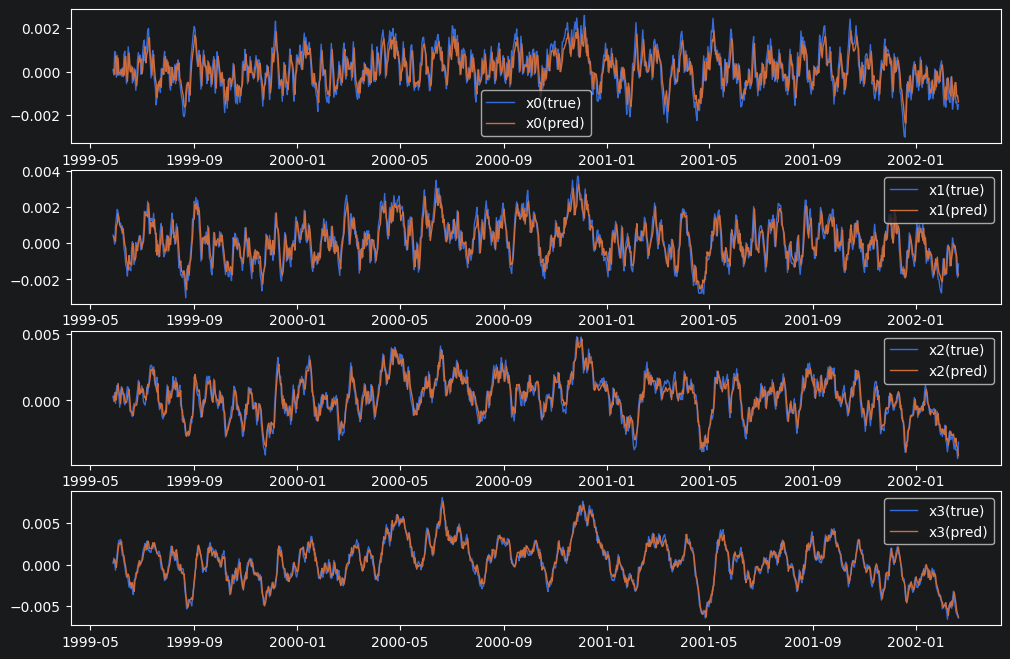

In [29]:
# モデルの予測値と真値の比較（線形性の確認）
pred_data = data.iloc[vl._lags :] - vl.residuals_  # vl.residuals_は訓練データの残差

fig, axes = plt.subplots(n_features, 1, figsize=(12, 2 * n_features))

for col, ax in zip(df.columns, axes):
    ax.plot(data[col], label=f"{col}(true)", linewidth=1)
    ax.plot(pred_data[col], label=f"{col}(pred)", linewidth=1)
    ax.legend()

### Noise의 독립성검정

In [30]:
vl.get_error_independence_p_values()

array([[0.        , 0.43761171, 0.49208251, 0.4645219 ],
       [0.43761171, 0.        , 0.60128564, 0.43637788],
       [0.49208251, 0.60128564, 0.        , 0.32398788],
       [0.4645219 , 0.43637788, 0.32398788, 0.        ]])

### Noise의 비정규성

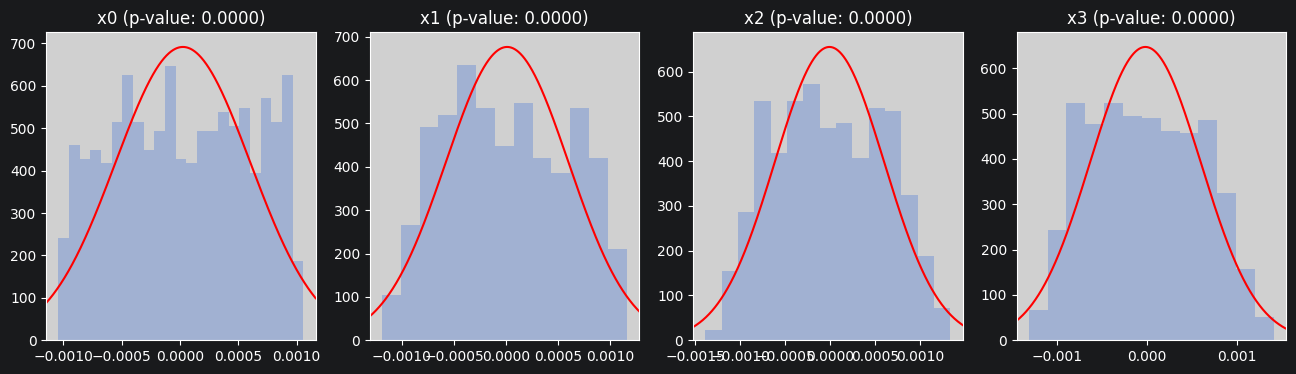

In [31]:
alpha = 0.05  # 有意水準。p値がこれを下回ったものの背景を灰色にする。
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 4))

for i, (col, ax) in enumerate(zip(data.columns, axes.ravel())):
    Xi = vl.residuals_[:, i]
    p_value = stats.shapiro(Xi)[1]  # p-value of Shapiro-Wilk test
    if p_value < alpha:
        ax.set_facecolor("#d0d0d0")
    ax.set_title(f"{col} (p-value: {p_value:.4f})")
    ax.hist(Xi, bins="stone", color="C0", alpha=0.3, density=True)
    xlim = ax.get_xlim()
    x_pdf = np.linspace(xlim[0], xlim[1], 1000)
    ax.plot(
        x_pdf, stats.norm.pdf(x_pdf, loc=Xi.mean(), scale=Xi.std()), c="r"
    )  # draw p.d.f. of Gaussian distribution
    ax.set_xlim(*xlim)